# **Classical ML for Authorship Signal in Lyric Poetry (EDA & Preprocessing)**

*An interpretability-focused exploratory analysis and authorship classification of poetic texts.*

by Natalia Zelenko

### **Project Overview**

This project is a **classical machine-learning text analysis** focused on identifying **authorial signal in poetic language** using interpretable, surface-level features.

The project includes three stages, each in a separate notebook:

1. **EDA and preprocessing design.**

2. Supervised multiclass classification.

3. Supplementary unsupervised analysis.

The same preprocessing pipeline defined at stage 1, is used for stages 2 and 3.

### **Dataset Overview**

**Texts:** English-language lyric poetry

**Historical scope:** late 20th-century / early 21st-century

**Source unit:** full poem

**Analytical unit:** text fragment

Fragments are created using linguistically motivated rules (stanzas or sentence clusters), preserving linguistic coherence rather than using fixed-length slicing.

Each fragment retains:

* author
* poem_id (to control fragment dependence)

---

**Poet and Text Selection Rationale**

Poets were selected using criteria such as stylistic signal being visible in surface linguistic features, and sufficient fragment yield for analysis.

Key choice constraints included:

* comparable historical period (to avoid trivial period effects),
* one period of each author's life (to avoid having different styles by the same author in a small dataset),
* mostly free verse (to avoid form dominating features).

## **0. Setup**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
CSV_PATH = "data/fragmented_original_expanded.csv"

In [ ]:
df_raw_orig = pd.read_csv(CSV_PATH)
display(df_raw_orig.head())
display(df_raw_orig.shape)

,fragment_id,poem_id,author,origin,fragment_index,text
0,1,collins_introduction_to_poetry,Billy Collins,original,0,I ask them to take a poem\r\nand hold it up to...
1,2,collins_introduction_to_poetry,Billy Collins,original,1,I say drop a mouse into a poem\r\nand watch hi...
2,3,collins_introduction_to_poetry,Billy Collins,original,2,I want them to waterski\r\nacross the surface ...
3,4,collins_introduction_to_poetry,Billy Collins,original,3,But all they want to do\r\nis tie the poem to ...
4,5,collins_introduction_to_poetry,Billy Collins,original,4,They begin beating it with a hose\r\nto find o...


(414, 6)

In [ ]:
df_raw_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   fragment_id     414 non-null    int64 
 1   poem_id         414 non-null    object
 2   author          414 non-null    object
 3   origin          414 non-null    object
 4   fragment_index  414 non-null    int64 
 5   text            414 non-null    object
dtypes: int64(2), object(4)
memory usage: 19.5+ KB


In [ ]:
print(df_raw_orig.loc[0, "text"])


I ask them to take a poem
and hold it up to the light
like a color slide

or press an ear against its hive.


## **1. Dataset Structure & Integrity**

In [ ]:
# Basic dataset size
n_fragments = len(df_raw_orig)
n_poems = df_raw_orig["poem_id"].nunique()
n_authors = df_raw_orig["author"].nunique()

print(f"Number of fragments: {n_fragments}")
print(f"Number of poems:     {n_poems}")
print(f"Number of authors:   {n_authors}")


Number of fragments: 414
Number of poems:     62
Number of authors:   5


In [ ]:
# Compute the number of fragments produced per poem
fragments_per_poem = df_raw_orig.groupby("poem_id").size()

# Descriptive statistics of fragment yield per poem
fragments_per_poem.describe().to_frame().T


,count,mean,std,min,25%,50%,75%,max
0,62.0,6.677419,2.559292,2.0,5.0,6.0,8.75,12.0


In [ ]:
# Compute per-author fragment and poem counts to assess fragment yield and balance
overview_by_author = (
    df_raw_orig
    .groupby("author")
    .agg(
        n_fragments=("fragment_id", "count"),
        n_poems=("poem_id", "nunique")
    )
    .sort_values("n_fragments", ascending=False)
)

overview_by_author


,n_fragments,n_poems
author,,
Seamus Heaney,85,12
Billy Collins,84,11
Sharon Olds,84,14
Ted Hughes,81,12
Louise Gluck,80,13


In [ ]:
# Compute percentage share of fragments per author
fragment_share_by_author = (
    overview_by_author["n_fragments"]
    / overview_by_author["n_fragments"].sum()
    * 100
).round(2)

fragment_share_by_author


,n_fragments
author,
Seamus Heaney,20.53
Billy Collins,20.29
Sharon Olds,20.29
Ted Hughes,19.57
Louise Gluck,19.32


**Interpretation**

The corpus shows a balanced fragment yield across authors. The average number of fragments per poem (~6-7) aligns with the design, and no single author dominates the dataset at the fragment level. Variation in fragment counts mainly reflects stylistic and structural differences between poems rather than preprocessing artifacts.

The current corpus consists of several hundred fragments, which is sufficient for exploratory analysis and interpretable classical NLP modeling.

## **2. Fragment Length Analysis**

In [ ]:
# Compute length metrics for each fragment
df_raw_orig["n_chars"] = df_raw_orig["text"].str.len()

# Word-level token count (whitespace-based)
df_raw_orig["n_tokens"] = df_raw_orig["text"].str.split().str.len()

# Approximate sentence count (based on sentence-ending punctuation)
df_raw_orig["n_sents"] = (
    df_raw_orig["text"]
    .str.count(r"[.!?]")
    .replace(0, 1)  # ensure minimum of 1 sentence per fragment
)

In [ ]:
# Descriptive statistics for fragment length
df_raw_orig[["n_chars", "n_tokens", "n_sents"]].describe().T

,count,mean,std,min,25%,50%,75%,max
n_chars,414.0,163.352657,68.688836,34.0,122.00,149.0,193.0,510.0
n_tokens,414.0,29.852657,12.566531,7.0,21.25,28.0,36.0,99.0
n_sents,414.0,1.594203,1.301727,1.0,1.00,1.0,2.0,20.0


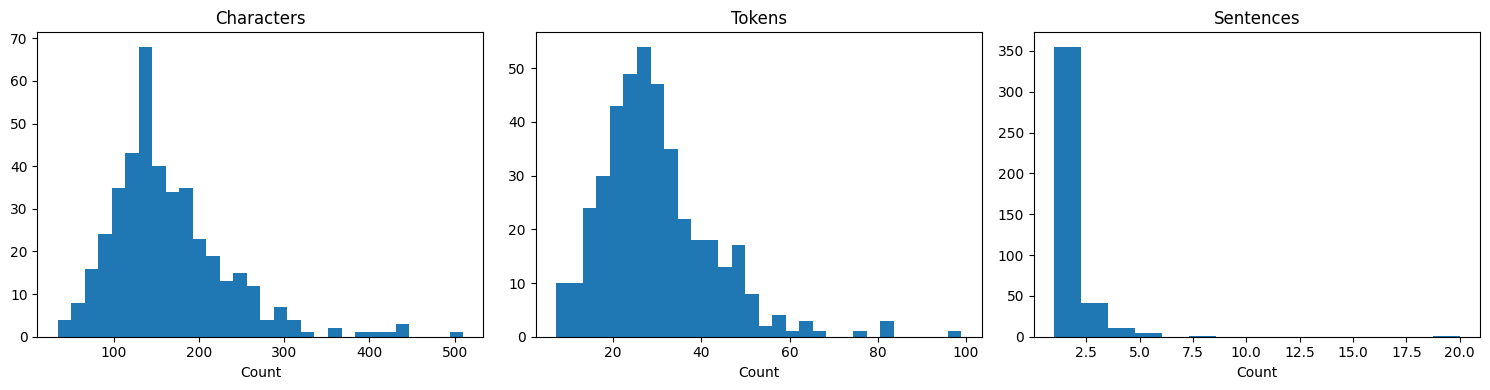

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Characters
axes[0].hist(df_raw_orig["n_chars"], bins=30)
axes[0].set_title("Characters")
axes[0].set_xlabel("Count")

# Tokens
axes[1].hist(df_raw_orig["n_tokens"], bins=30)
axes[1].set_title("Tokens")
axes[1].set_xlabel("Count")

# Sentences
axes[2].hist(df_raw_orig["n_sents"], bins=15)
axes[2].set_title("Sentences")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.show()


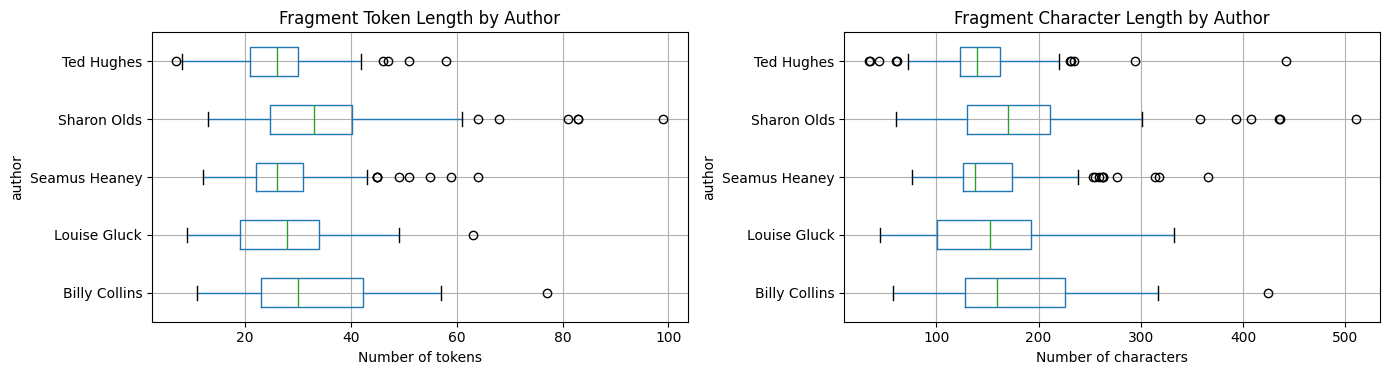

<Figure size 800x300 with 0 Axes>

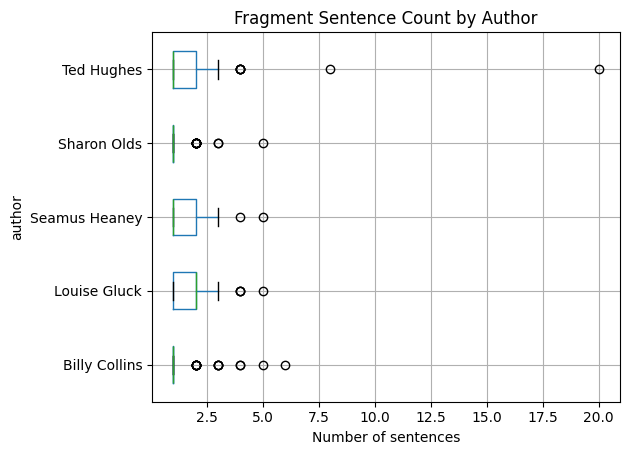

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Token length by author
df_raw_orig.boxplot(
    column="n_tokens",
    by="author",
    vert=False,
    ax=axes[0]
)
axes[0].set_title("Fragment Token Length by Author")
axes[0].set_xlabel("Number of tokens")

# Character length by author
df_raw_orig.boxplot(
    column="n_chars",
    by="author",
    vert=False,
    ax=axes[1]
)
axes[1].set_title("Fragment Character Length by Author")
axes[1].set_xlabel("Number of characters")

plt.suptitle("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))

df_raw_orig.boxplot(
    column="n_sents",
    by="author",
    vert=False
)

plt.title("Fragment Sentence Count by Author")
plt.suptitle("")
plt.xlabel("Number of sentences")
plt.tight_layout()
plt.show()



In [ ]:
# List the shortest fragments by token count
df_raw_orig[
    ["author", "poem_id", "fragment_id", "n_tokens", "n_chars", "n_sents", "text"]
].sort_values("n_tokens", ascending=True).head(5)


,author,poem_id,fragment_id,n_tokens,n_chars,n_sents,text
303,Ted Hughes,hughes_examination_at_the_womb_door,304,7,44,2,"Given, stolen, or held pending trial?\r\nHeld."
336,Ted Hughes,hughes_that_morning,337,8,34,1,That had let the world pass away –
340,Ted Hughes,hughes_that_morning,341,8,35,1,So we found the end of our journey.
95,Louise Gluck,gluck_metamorphosis,96,9,53,1,Then his flushed face \r\nturned away from the...
299,Ted Hughes,hughes_crows_fall,300,10,62,1,"At his battle cry trees grew suddenly old,\r\n..."


In [ ]:
# List the longest fragments by token count
df_raw_orig[
    ["author", "poem_id", "fragment_id", "n_tokens", "n_chars", "n_sents", "text"]
].sort_values("n_tokens", ascending=False).head(5)


,author,poem_id,fragment_id,n_tokens,n_chars,n_sents,text
282,Sharon Olds,olds_the_race,283,99,510,1,"I lumbered up the moving stairs,\r\nat the top..."
406,Sharon Olds,olds_the_food_thief,407,83,435,1,He turns to them \r\nwith all the eloquence of...
407,Sharon Olds,olds_the_food_thief,408,83,408,1,His lips are open to his brothers as the body ...
284,Sharon Olds,olds_the_race,285,81,436,2,"The jet\r\nwas full, and people's hair was shi..."
21,Billy Collins,collins_marginalia,22,77,424,1,"I was just beginning high school then,\r\nread..."


In [ ]:
# Fragment length extremes grouped by poem
df_raw_orig.groupby("poem_id")["n_tokens"].agg(["min", "max", "mean"]).sort_values("max", ascending=False).head(5)


,min,max,mean
poem_id,,,
olds_the_race,26,99,54.250000
olds_the_food_thief,24,83,52.200000
collins_marginalia,15,77,36.250000
olds_the_language_of_the_brag,36,68,52.400000
heaney_the_strand_at_lough_beg,17,64,39.222222


**Interpretation**

Fragment lengths show a right-skewed distribution across characters, tokens, and sentence counts, with most fragments falling into a moderate and consistent range. The average fragment contains approximately 30 tokens and 1-2 sentences, aligning with the stanza-level or sentence-cluster fragmentation approach.

Very short and very long fragments are present but correspond to identifiable stylistic patterns rather than preprocessing errors. Longer fragments are concentrated in a small number of narrative-heavy poems, while shorter fragments tend to reflect concise rhetorical units.

Overall, the corpus shows natural structural variation without evidence of corrupted text, empty fragments, or systematic imbalance.

## **3. Vocabulary & Sparsity Audit (Descriptive)**

### **3.1 Lexical Density**

In [ ]:
# EDA-only tokenizer, NOT the final preprocessing choice
TOKEN_PATTERN = re.compile(r"[a-zA-Z']+")

def tokenize(text):
    return TOKEN_PATTERN.findall(text.lower())


In [ ]:
df_raw_orig["tokens"] = df_raw_orig["text"].apply(tokenize)

all_tokens = [tok for toks in df_raw_orig["tokens"] for tok in toks]


In [ ]:
total_vocab = set(all_tokens)
total_vocab_size = len(total_vocab)

vocab_size_by_author = (
    df_raw_orig.explode("tokens")
      .groupby("author")["tokens"]
      .nunique()
      .sort_values(ascending=False)
)

display(total_vocab_size)
display(vocab_size_by_author)


3237

,tokens
author,
Seamus Heaney,1106
Billy Collins,1061
Sharon Olds,983
Ted Hughes,890
Louise Gluck,828


In [ ]:
# Token count per author
token_count_by_author = (
    df_raw_orig.explode("tokens")
      .groupby("author")["tokens"]
      .count()
)

# Vocabulary size per 1000 tokens
vocab_per_1k_tokens = (
    vocab_size_by_author / token_count_by_author * 1000
).round(2)

vocab_per_1k_tokens_df = (
    vocab_per_1k_tokens
        .rename("vocab_per_1k_tokens")
        .to_frame()
        .sort_values("vocab_per_1k_tokens", ascending=False)
)

vocab_per_1k_tokens_df


,vocab_per_1k_tokens
author,
Seamus Heaney,458.16
Ted Hughes,418.82
Billy Collins,383.86
Louise Gluck,373.65
Sharon Olds,330.98


After normalization by token count, authors show clear differences in lexical density.

### **3.2 Top Tokens**

In [ ]:
token_freq_all = Counter(all_tokens)

token_freq_by_author = {
    author: Counter(
        toks for sublist in group["tokens"] for toks in sublist
    )
    for author, group in df_raw_orig.groupby("author")
}


In [ ]:
TOP_N = 20

top_tokens_overall = token_freq_all.most_common(TOP_N)

print("TOP 20 TOKENS")
pd.DataFrame(
    top_tokens_overall,
    columns=["token", "count"]
)


TOP 20 TOKENS


,token,count
0,the,878
1,and,393
2,a,314
3,of,305
4,i,296
5,to,272
6,in,240
7,you,132
8,it,129
9,my,118


In [ ]:
top_tokens_per_author = {}

for author, counter in token_freq_by_author.items():
    total_tokens = sum(counter.values())

    top_tokens_per_author[author] = [
        (token, count / total_tokens)
        for token, count in counter.most_common(TOP_N)
    ]

print("TOP 20 TOKENS BY AUTHOR")
for author, tokens in top_tokens_per_author.items():
    print(f"\n{author}")
    display(
        pd.DataFrame(tokens, columns=["token", "relative_frequency"])
            .round(4)
    )


TOP 20 TOKENS BY AUTHOR

Billy Collins


,token,relative_frequency
0,the,0.0814
1,a,0.0391
2,of,0.0308
3,and,0.0289
4,to,0.0221
5,in,0.0203
6,i,0.0199
7,you,0.0166
8,on,0.0098
9,that,0.0090



Louise Gluck


,token,relative_frequency
0,the,0.0654
1,to,0.0320
2,i,0.0275
3,in,0.0226
4,of,0.0185
5,a,0.0176
6,you,0.0153
7,my,0.0153
8,and,0.0153
9,that,0.0108



Seamus Heaney


,token,relative_frequency
0,the,0.0667
1,and,0.0439
2,a,0.0273
3,of,0.0232
4,in,0.0186
5,to,0.0166
6,i,0.0149
7,you,0.0108
8,that,0.0099
9,was,0.0083



Sharon Olds


,token,relative_frequency
0,the,0.0697
1,and,0.0364
2,i,0.0347
3,to,0.0236
4,of,0.0232
5,a,0.0202
6,in,0.0182
7,they,0.0158
8,it,0.0155
9,my,0.0121



Ted Hughes


,token,relative_frequency
0,the,0.0659
1,and,0.0306
2,of,0.0254
3,i,0.0193
4,a,0.0193
5,in,0.0165
6,it,0.0141
7,to,0.0141
8,this,0.0099
9,is,0.0094


The most frequent tokens across the corpus and per author are dominated by function words, as expected for English poetry. While the same core vocabulary appears across authors, relative frequency differences suggest stylistic variation at the distributional level.

### **3.3 Token Frequency Distribution**

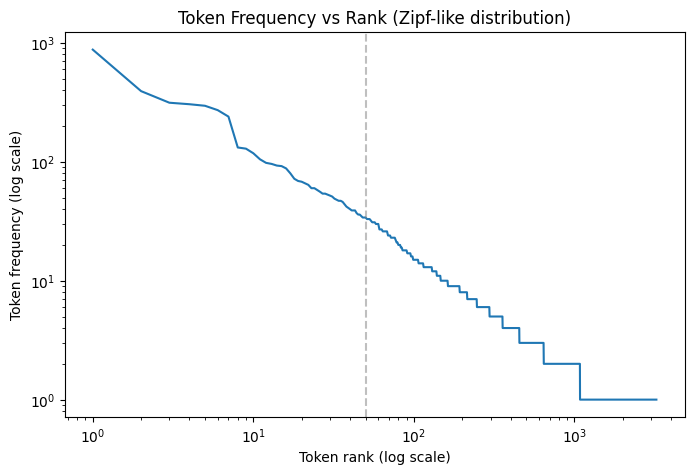

In [ ]:
# Zipf-like token frequency distribution with rank axis

freq_values = np.array(
    sorted(token_freq_all.values(), reverse=True)
)

ranks = np.arange(1, len(freq_values) + 1)

plt.figure(figsize=(8, 5))
plt.plot(ranks, freq_values)
plt.axvline(50, color="gray", linestyle="--", alpha=0.5)  # head / tail boundary
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Token rank (log scale)")
plt.ylabel("Token frequency (log scale)")
plt.title("Token Frequency vs Rank (Zipf-like distribution)")
plt.show()


The observed Zipf-like distribution indicates a typical natural-language frequency structure and supports the use of TF-IDF-based representations.

### **Interpretation**

The lexical analysis shows that no author exhibits extreme lexical dominance or impoverishment. After normalization by token count, authors display clear differences in lexical density consistent with stylistic tendencies rather than corpus size effects.

Function words dominate both at the corpus and author level, while differences between authors emerge primarily through relative frequency patterns rather than distinct lexical items. The global token distribution follows a typical natural-language pattern, with a small set of high-frequency tokens and a long tail of rare words.

Overall, the corpus appears structurally clean and linguistically consistent, supporting the use of TF-IDF as a baseline representation for subsequent analysis.

## **4. Punctuation & Surface‑Feature Audit**

In [ ]:
PUNCT_PATTERNS = {
    "comma_count": r",",

    # Count BOTH typographic dashes and hyphen-minus separately (source inconsistency)
    "dash_typographic_count": r"[—–]",  # em dash + en dash
    "dash_hyphen_count": r"-",          # hyphen-minus

    "colon_semicolon_count": r"[:;]",
    "parenthesis_count": r"[()]",

    # straight + curly quotes
    "quote_count": r"[\"“”‘’]"
}


In [ ]:
# feature extraction on fragments
def count_pattern(text: str, pattern: str) -> int:
    if not isinstance(text, str):
        return 0
    return len(re.findall(pattern, text))

df_punct = df_raw_orig.copy()

for col, pat in PUNCT_PATTERNS.items():
    df_punct[col] = df_punct["text"].apply(lambda t: count_pattern(t, pat))

# sample output
df_punct[["author"] + list(PUNCT_PATTERNS.keys())].head(5)


,author,comma_count,dash_typographic_count,dash_hyphen_count,colon_semicolon_count,parenthesis_count,quote_count
0,Billy Collins,0,0,0,0,0,0
1,Billy Collins,1,0,0,0,0,1
2,Billy Collins,0,0,0,0,0,1
3,Billy Collins,0,0,0,0,0,0
4,Billy Collins,0,0,0,0,0,0


In [ ]:
# per-author summary table
feature_cols = list(PUNCT_PATTERNS.keys())

author_punct_summary = (
    df_punct
    .groupby("author")[feature_cols]
    .agg(["mean", "median", "std", "sum"])
    .round(2)
)

author_punct_summary.T


author                         Billy Collins  Louise Gluck  Seamus Heaney  \
comma_count            mean             2.24          2.34           1.78   
                       median           2.00          2.00           1.00   
                       std              1.98          1.83           1.63   
                       sum            188.00        187.00         151.00   
dash_typographic_count mean             0.17          0.26           0.05   
                       median           0.00          0.00           0.00   
                       std              0.49          0.50           0.21   
                       sum             14.00         21.00           4.00   
dash_hyphen_count      mean             0.26          0.04           0.28   
                       median           0.00          0.00           0.00   
                       std              0.58          0.25           0.55   
                       sum             22.00          3.00          24.00   
colon_semicolon_count  mean             0.01          0.40           0.16   
                       median           0.00          0.00           0.00   
                       std              0.11          0.61           0.40   
                       sum              1.00         32.00          14.00   
parenthesis_count      mean             0.00          0.00           0.00   
                       median           0.00          0.00           0.00   
                       std              0.00          0.00           0.00   
                       sum              0.00          0.00           0.00   
quote_count            mean             0.45          0.42           0.19   
                       median           0.00          0.00           0.00   
                       std              1.45          0.99           0.75   
                       sum             38.00         34.00          16.00   

author                         Sharon Olds  Ted Hughes  
comma_count            mean           3.30        1.68  
                       median         3.00        1.00  
                       std            2.17        1.72  
                       sum          277.00      136.00  
dash_typographic_count mean           0.17        0.07  
                       median         0.00        0.00  
                       std            0.46        0.26  
                       sum           14.00        6.00  
dash_hyphen_count      mean           0.21        0.31  
                       median         0.00        0.00  
                       std            0.60        0.68  
                       sum           18.00       25.00  
colon_semicolon_count  mean           0.02        0.41  
                       median         0.00        0.00  
                       std            0.15        0.72  
                       sum            2.00       33.00  
parenthesis_count      mean           0.00        0.00  
                       median         0.00        0.00  
                       std            0.00        0.00  
                       sum            0.00        0.00  
quote_count            mean           0.17        0.10  
                       median         0.00        0.00  
                       std            0.56        0.51  
                       sum           14.00        8.00

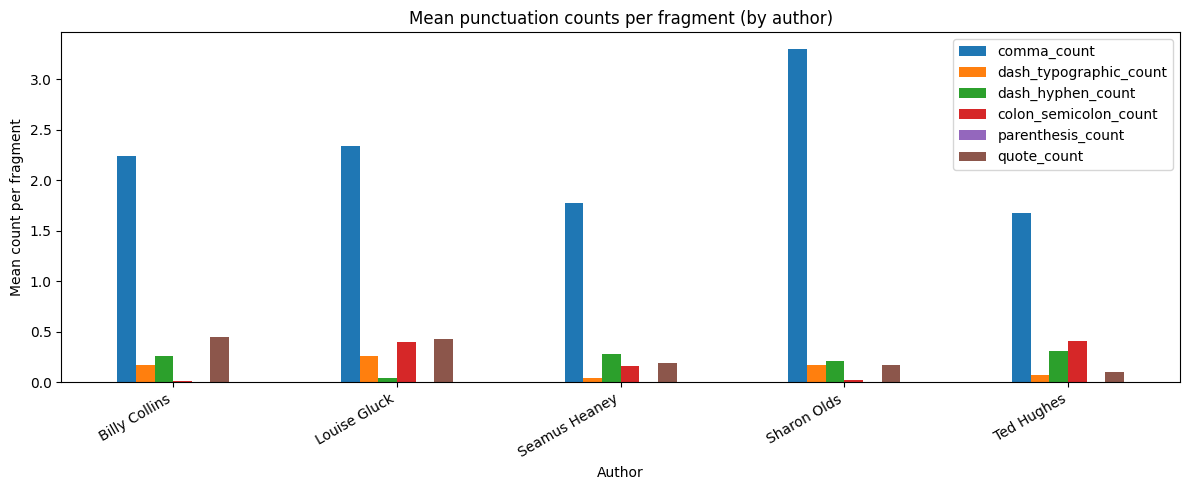

In [ ]:
# bar plot of MEAN counts per author
mean_by_author = df_punct.groupby("author")[feature_cols].mean()

mean_by_author.plot(kind="bar", figsize=(12, 5))
plt.title("Mean punctuation counts per fragment (by author)")
plt.xlabel("Author")
plt.ylabel("Mean count per fragment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

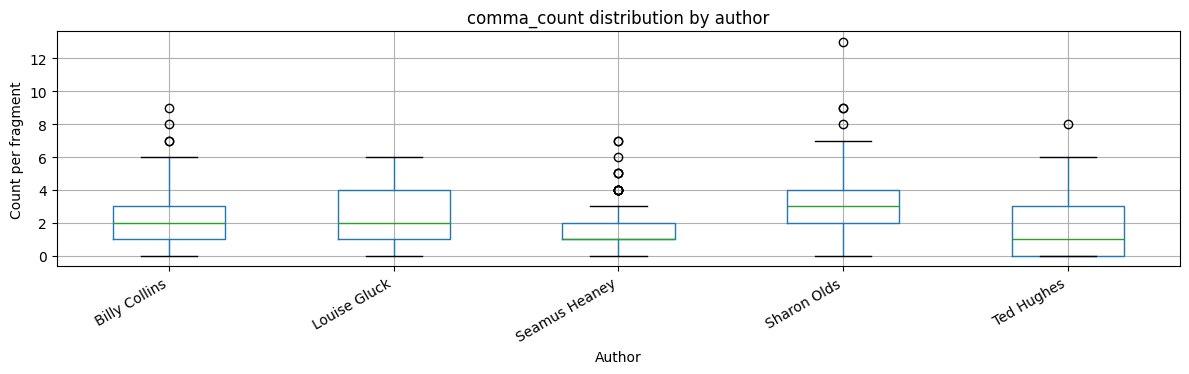

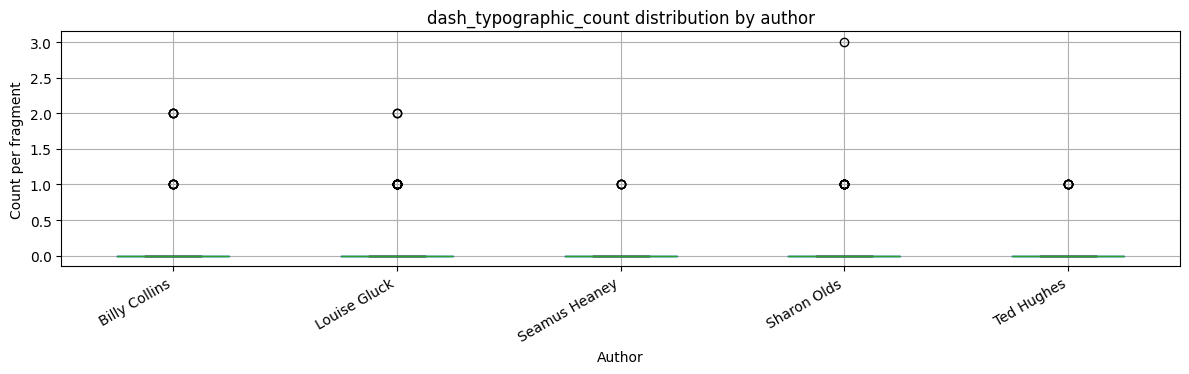

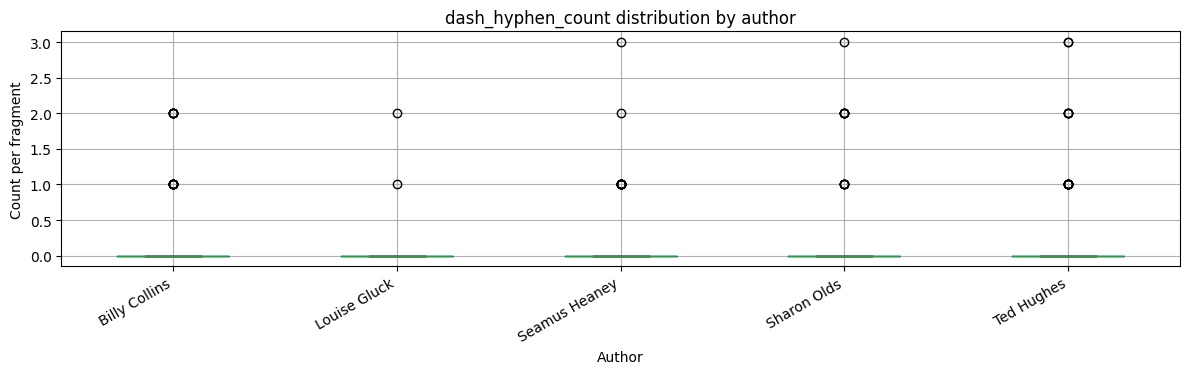

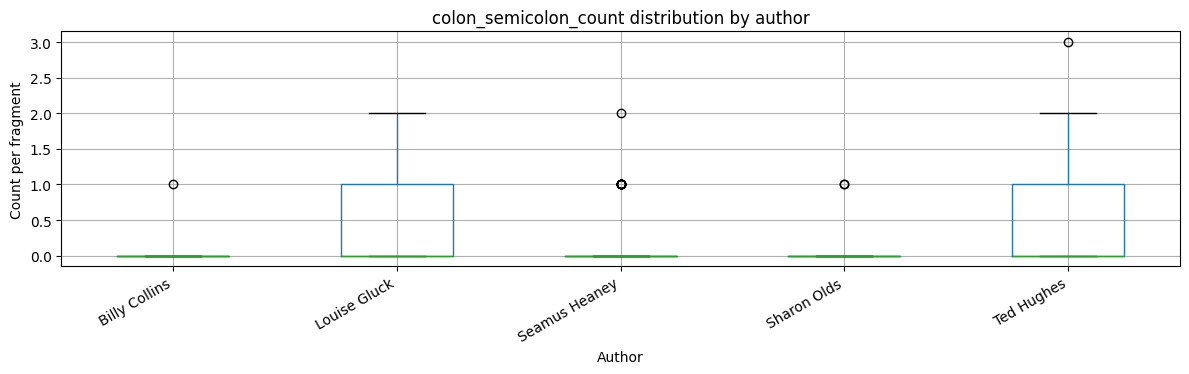

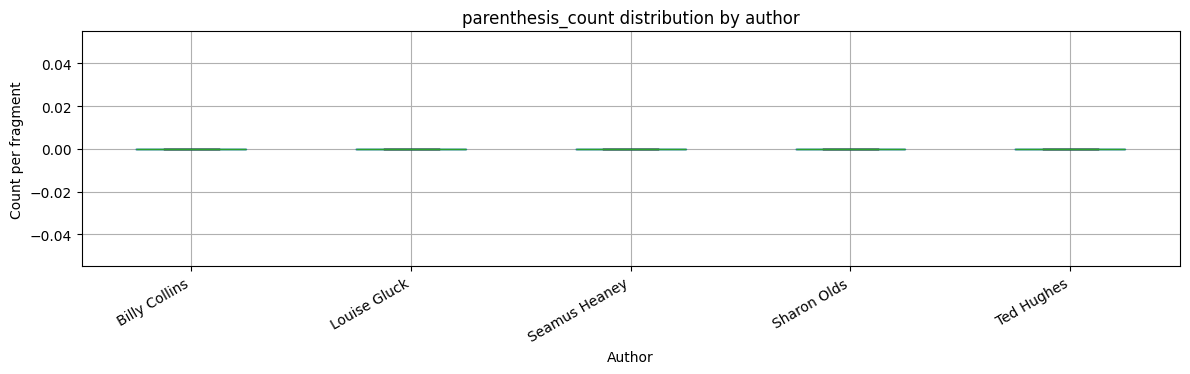

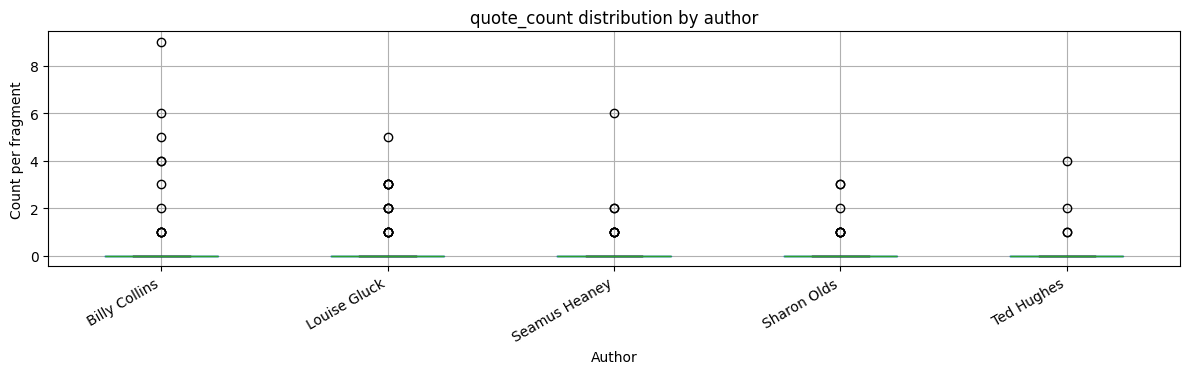

In [ ]:
#boxplots (distribution per author)
for feat in feature_cols:
    df_punct.boxplot(column=feat, by="author", figsize=(12, 4))
    plt.title(f"{feat} distribution by author")
    plt.suptitle("")
    plt.xlabel("Author")
    plt.ylabel("Count per fragment")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:
# punctuation per 100 tokens
if "token_count" not in df_punct.columns:
    TOKEN_PATTERN = re.compile(r"[a-zA-Z']+")
    df_punct["token_count"] = df_punct["text"].apply(lambda t: len(TOKEN_PATTERN.findall(t.lower())))

for feat in feature_cols:
    df_punct[f"{feat}_per_100_tokens"] = (df_punct[feat] / df_punct["token_count"].replace(0, pd.NA)) * 100

density_cols = [f"{feat}_per_100_tokens" for feat in feature_cols]

density_by_author = df_punct.groupby("author")[density_cols].mean().round(2)
density_by_author.T


author,Billy Collins,Louise Gluck,Seamus Heaney,Sharon Olds,Ted Hughes
comma_count_per_100_tokens,6.60,7.67,6.40,9.39,6.94
dash_typographic_count_per_100_tokens,0.46,1.04,0.14,0.56,0.42
dash_hyphen_count_per_100_tokens,0.85,0.09,1.05,0.60,1.01
colon_semicolon_count_per_100_tokens,0.03,1.46,0.60,0.05,1.40
parenthesis_count_per_100_tokens,0.00,0.00,0.00,0.00,0.00
quote_count_per_100_tokens,1.58,1.64,0.65,0.50,0.56


**Interpretation**

Section 4 shows that authors differ not only in lexical choice but also in measurable surface syntactic habits such as punctuation density. These differences persist after normalization by token count, suggesting genuine stylistic variation rather than fragment-length effects. At the same time, some punctuation features remain sparse or unstable.

## **5. Preprocessing Design**

### **5.1 Preliminary Text Cleaning**

At this stage, all meaningful information (case, punctuation, line breaks) is preserved. The cleaning process is limited to formatting-related noise removal.

In [ ]:
# minimal text cleaning
def clean_text_minimal(text):

    if not isinstance(text, str):
        return text

    # remove any fragment boundary markers
    text = re.sub(r'[ \t]*---[ \t]*', ' ', text)

    # normalize horizontal whitespace (spaces and tabs only)
    text = re.sub(r'[ \t]+', ' ', text)

    # strip leading/trailing whitespace while preserving newlines
    return text.strip()

In [ ]:
# apply to original fragments
df_raw_orig['text_clean'] = df_raw_orig['text'].apply(clean_text_minimal)


In [ ]:
# sanity check: original vs cleaned text
df_raw_orig[['text', 'text_clean']].sample(5)


,text,text_clean
313,"I sit in the top of the wood, my eyes closed.\...","I sit in the top of the wood, my eyes closed.\..."
246,It seems\r\nno time since I would help him to ...,It seems\r\nno time since I would help him to ...
382,"Do you know what I was, how I lived? You know...","Do you know what I was, how I lived? You know\..."
228,"they are about to graduate, they are about to ...","they are about to graduate, they are about to ..."
278,A young man\r\nwith a dark brown moustache tol...,A young man\r\nwith a dark brown moustache tol...


In [ ]:
# column check after Section 5.1
df_raw_orig.columns


Index(['fragment_id', 'poem_id', 'author', 'origin', 'fragment_index', 'text',
       'n_chars', 'n_tokens', 'n_sents', 'tokens', 'text_clean'],
      dtype='object')

### **5.2 Tokenization strategy**

- **Chosen representation: TF-IDF**  
  Based on the EDA results and project goals, TF-IDF was selected as the baseline text representation.

- **Word-level tokenization**  
  The analysis focuses on lexical and stylistic variation at the word level.

- **Explicit regex-based tokenizer**  
  A regex-defined tokenizer is used to keep tokenization rules transparent and consistent across all tasks.

- **Punctuation treated as separators (not tokens)**  
  Punctuation is preserved in the raw text but treated as separators during tokenization to avoid inflating the vocabulary with punctuation-only tokens.

In [ ]:
# word-level tokenizer:
TOKEN_PATTERN = r"[A-Za-z]+"


In [ ]:
# how many tokens per fragment under the chosen rule

token_regex = re.compile(TOKEN_PATTERN)

df_raw_orig['n_tokens_model'] = df_raw_orig['text_clean'].apply(
    lambda x: len(token_regex.findall(x.lower())) if isinstance(x, str) else 0
)

df_raw_orig['n_tokens_model'].describe()


,n_tokens_model
count,414.000000
mean,30.330918
std,12.752407
min,7.000000
25%,22.000000
50%,28.000000
75%,36.000000
max,99.000000


### **5.3 Vectorization**

- **TF-IDF representation**  
  TF-IDF is used as the baseline vector representation to highlight words characteristic of specific fragments and authors while down-weighting ubiquitous terms.

- **Word-level features only**  
  Vectorization operates on the word tokens defined in Section 5.2.

- **Unigrams only**  
  Unigrams are used to keep the feature space compact and interpretable.

- **No stopword removal**  
  Function words are preserved because they may carry stylistic and authorial signal.

**At this stage, TF-IDF vectorization is fitted on the full corpus to inspect feature-space properties and validate preprocessing choices. During modeling, vectorization will be fitted on the training split only to avoid data leakage.**

In [ ]:
# define TF-IDF vectorizer with chozen settings
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=TOKEN_PATTERN,   # from Section 5.2
    lowercase=True,               # remove case
    ngram_range=(1, 1),             # unigrams only
    stop_words=None                # no stopword removal
)

In [ ]:
# fit and transform cleaned text
X_tfidf = tfidf_vectorizer.fit_transform(df_raw_orig['text_clean'])

In [ ]:
# sanity checks
X_tfidf.shape

(414, 3201)

In [ ]:
# vocabulary size
len(tfidf_vectorizer.vocabulary_)

3201

### **5.4 Note on metadata and data leakage**

Throughout preprocessing, fragment-level metadata is preserved for traceability and experimental control. **During modeling, train/test splits must respect `poem_id`, since fragments derived from the same poem are not independent observations.**

###
---
**Conclusion**

Section 5 defines a minimal and fully interpretable preprocessing pipeline with explicitly specified tokenization and vectorization rules. The resulting TF-IDF representation serves as a baseline for downstream modeling, while preserved metadata supports traceability and leakage-aware experimental design.


## **6. Supplementary Exploratory Analysis**

### **6.1 Author Vocabulary Overlap**

To assess lexical similarity between authors, pairwise Jaccard similarity is computed between their vocabularies. Each author's vocabulary is defined as the set of unique word tokens appearing in their fragments after the preprocessing.


In [ ]:
# reuse the token pattern from Section 5.2
token_regex = re.compile(TOKEN_PATTERN)

# build vocabulary set per author
author_vocab = {}

for author, group in df_raw_orig.groupby('author'):
    tokens = []
    for text in group['text_clean']:
        if isinstance(text, str):
            tokens.extend(token_regex.findall(text.lower()))
    author_vocab[author] = set(tokens)

# inspect vocabulary sizes
pd.Series({a: len(v) for a, v in author_vocab.items()})


,0
Billy Collins,1058
Louise Gluck,822
Seamus Heaney,1105
Sharon Olds,973
Ted Hughes,875


In [ ]:
# compute pairwise Jaccard similarity between authors
authors = list(author_vocab.keys())
jaccard_matrix = pd.DataFrame(
    index=authors,
    columns=authors,
    dtype=float
)

for a1 in authors:
    for a2 in authors:
        v1 = author_vocab[a1]
        v2 = author_vocab[a2]
        jaccard_matrix.loc[a1, a2] = len(v1 & v2) / len(v1 | v2)

jaccard_matrix


,Billy Collins,Louise Gluck,Seamus Heaney,Sharon Olds,Ted Hughes
Billy Collins,1.000000,0.191381,0.155449,0.189110,0.163757
Louise Gluck,0.191381,1.000000,0.170717,0.204698,0.180932
Seamus Heaney,0.155449,0.170717,1.000000,0.176005,0.165391
Sharon Olds,0.189110,0.204698,0.176005,1.000000,0.186136
Ted Hughes,0.163757,0.180932,0.165391,0.186136,1.000000


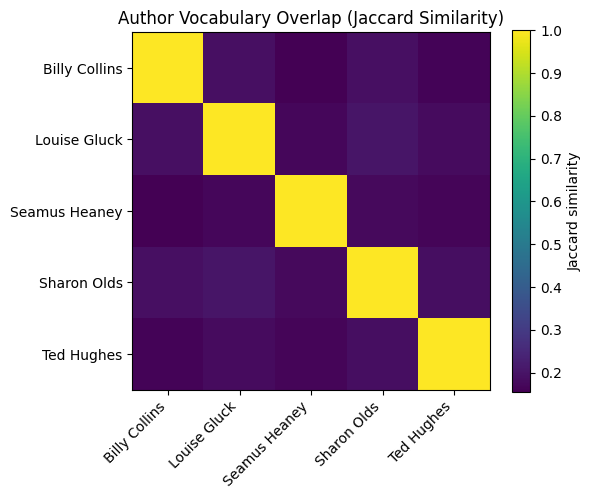

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(jaccard_matrix.values, interpolation='nearest')
plt.colorbar(label='Jaccard similarity')

plt.xticks(range(len(authors)), authors, rotation=45, ha='right')
plt.yticks(range(len(authors)), authors)

plt.title('Author Vocabulary Overlap (Jaccard Similarity)')
plt.tight_layout()
plt.show()

The heatmap shows low to moderate vocabulary overlap between author pairs, with Jaccard similarity values generally ranging from approximately 0.15 to 0.20. No pair exhibits exceptionally high lexical overlap, suggesting that authors maintain distinct vocabularies at the fragment level. Slightly higher overlaps between some pairs may contribute to downstream classification confusability.

### **6.2 Fragment Internal Structure**

This section examines structural properties of fragments not captured by lexical features, focusing on line counts and line-length variability across authors. These measures provide additional context for interpreting stylistic and fragmentation differences.

In [ ]:
# helper functions

def line_lengths(text):
    if not isinstance(text, str):
        return []
    lines = [ln for ln in text.split('\n') if ln.strip() != '']
    return [len(ln) for ln in lines]


def line_count(text):
    if not isinstance(text, str):
        return 0
    return sum(1 for ln in text.split('\n') if ln.strip() != '')


In [ ]:
# compute structural features per fragment
df_raw_orig['n_lines'] = df_raw_orig['text_clean'].apply(line_count)
df_raw_orig['line_length_var'] = df_raw_orig['text_clean'].apply(
    lambda x: np.var(line_lengths(x)) if len(line_lengths(x)) > 1 else 0.0
)

df_raw_orig[['n_lines', 'line_length_var']].describe().T

,count,mean,std,min,25%,50%,75%,max
n_lines,414.0,4.333333,1.667232,1.0,3.000000,4.000000,5.000000,13.0
line_length_var,414.0,66.377485,74.021243,0.0,16.916667,39.716111,91.370748,576.0


<Figure size 700x400 with 0 Axes>

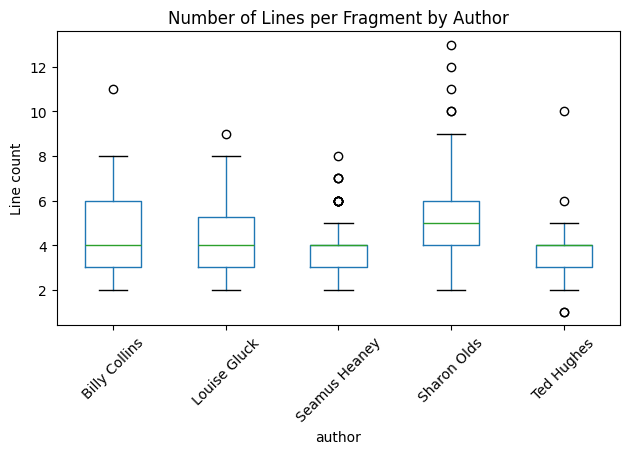

In [ ]:
# boxplot: number of lines per fragment by author
plt.figure(figsize=(7, 4))
df_raw_orig.boxplot(column='n_lines', by='author', grid=False)
plt.title('Number of Lines per Fragment by Author')
plt.suptitle('')
plt.ylabel('Line count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 700x400 with 0 Axes>

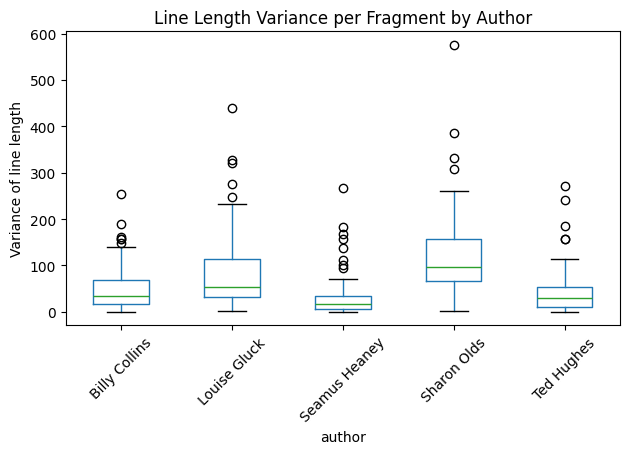

In [ ]:
# boxplot: line length variance by author
plt.figure(figsize=(7, 4))
df_raw_orig.boxplot(column='line_length_var', by='author', grid=False)
plt.title('Line Length Variance per Fragment by Author')
plt.suptitle('')
plt.ylabel('Variance of line length')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The distributions show systematic differences in fragment internal structure across authors. Sharon Olds exhibits the highest variability in both line count and line-length variance, while Seamus Heaney shows comparatively compact and uniform fragments. The remaining authors fall between these extremes, suggesting author-specific structural tendencies that complement lexical differences.